# 03a — Training EfficientNetB0

**Fase 2** — Training EfficientNetB0 x 5 seed x 2 stage (freeze -> fine-tune)

**Referensi:** Proposal 3.3.6, 3.3.7

---

**Konfigurasi:**
- Stage 1: Freeze base model, LR=1e-3, 10 epoch
- Stage 2: Unfreeze 20 layer terakhir, LR=1e-4, 10 epoch
- Callbacks: EarlyStopping(p=5), ReduceLROnPlateau(f=0.5,p=5), ModelCheckpoint
- 5 seed: [42, 123, 2024, 7, 99]

**Output:**
- Checkpoint: `models/efficientnetb0_seed{n}.keras`
- History JSON: `results/history_efficientnetb0_seed{n}.json`

In [1]:
%cd /kaggle/working
!git clone -b training_efficientnetb0 https://github.com/milalestari/TUGAS-AKHIR.git

/kaggle/working
Cloning into 'TUGAS-AKHIR'...
remote: Enumerating objects: 3626, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 3626 (delta 41), reused 50 (delta 21), pack-reused 3550 (from 1)
Receiving objects: 100% (3626/3626), 1.04 GiB | 45.41 MiB/s, done.
Resolving deltas: 100% (96/96), done.
Updating files: 100% (7840/7840), done.


In [2]:
# ================================================================
# BOOTSTRAP: Auto-detect project root + setup paths
# ================================================================
from pathlib import Path
import os, sys

def find_project_root():
    candidates = [Path.cwd()]
    candidates.extend(Path.cwd().parents)
    candidates.append(Path("/kaggle/working/TUGAS-AKHIR"))
    for path in candidates:
        if (path / "requirements.txt").exists() and (path / "src").exists():
            return path
    raise RuntimeError(
        "PROJECT_ROOT TUGAS-AKHIR tidak ditemukan."
        " Pastikan notebook dijalankan dari folder repo."
    )

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

# Dataset (Kaggle Dataset privat: dataset-cuaca-split)
INPUT_DIR = Path("/kaggle/input/datasets/furqanramadhan/dataset-cuaca-split")
if not INPUT_DIR.exists():
    INPUT_DIR = PROJECT_ROOT / "dataset" / "split"

DATA_DIR    = INPUT_DIR
MODELS_DIR  = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

print("PROJECT_ROOT :", PROJECT_ROOT)
print("INPUT_DIR   :", INPUT_DIR)
print("CWD         :", Path.cwd())

assert INPUT_DIR.exists(), f"INPUT_DIR tidak ditemukan: {INPUT_DIR}"

PROJECT_ROOT : /kaggle/working/TUGAS-AKHIR
INPUT_DIR   : /kaggle/input/datasets/furqanramadhan/dataset-cuaca-split
CWD         : /kaggle/working/TUGAS-AKHIR


## Langkah 2 — Import Library

In [3]:
import random, json, time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import tensorflow as tf
print('TensorFlow:', tf.__version__)
print('GPU      :', bool(tf.config.list_physical_devices('GPU')))

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_recall_fscore_support
)

from src.model_builder import (
    build_model, unfreeze_for_fine_tune,
    build_callbacks, print_model_info,
    SEEDS, EPOCHS_STAGE1, EPOCHS_STAGE2,
    STAGE1_LR, STAGE2_LR,
    EFFICIENTNET_UNFREEZE,
    IMG_SIZE, NUM_CLASSES, CLASS_NAMES
)

from src.train import train_two_stage

from src.data_pipeline import build_tf_dataset

print('All imports OK')
print('SEEDS           :', SEEDS)
print('EPOCHS_STAGE1   :', EPOCHS_STAGE1)
print('EPOCHS_STAGE2   :', EPOCHS_STAGE2)
print('EFFICIENTNET_UNFREEZE:', EFFICIENTNET_UNFREEZE)

TensorFlow: 2.20.0
GPU      : True
All imports OK
SEEDS           : [42, 123, 2024, 7, 99]
EPOCHS_STAGE1   : 10
EPOCHS_STAGE2   : 10
EFFICIENTNET_UNFREEZE: 20


## Langkah 3 — Verifikasi Dataset & Paths

In [4]:
print('Verifikasi paths:')
print('  PROJECT_ROOT:', PROJECT_ROOT)
print('  INPUT_DIR  :', INPUT_DIR)
print('  exists?   :', INPUT_DIR.exists())

seed_folders = sorted([f.name for f in INPUT_DIR.iterdir() if f.is_dir()]) if INPUT_DIR.exists() else []
print('  Seeds     :', seed_folders)

Verifikasi paths:
  PROJECT_ROOT: /kaggle/working/TUGAS-AKHIR
  INPUT_DIR  : /kaggle/input/datasets/furqanramadhan/dataset-cuaca-split
  exists?   : True
  Seeds     : ['seed123', 'seed2024', 'seed42', 'seed7', 'seed99']


## Langkah 4 — Load Datasets (Demo: seed=42)

**Demo dengan seed=42. Cell 12 menjalankan semua 5 seed.**

In [5]:
DEMO_SEED = 42
preprocess_eff = tf.keras.applications.efficientnet.preprocess_input

ds_train = build_tf_dataset(
    seed=DEMO_SEED, subset='train',
    preprocess_fn=preprocess_eff, augment=True, batch_size=32
)
ds_val = build_tf_dataset(
    seed=DEMO_SEED, subset='val',
    preprocess_fn=preprocess_eff, augment=False, batch_size=32
)
ds_test = build_tf_dataset(
    seed=DEMO_SEED, subset='test',
    preprocess_fn=preprocess_eff, augment=False, batch_size=32
)

print('Train :', len(list(ds_train)), 'batches')
print('Val   :', len(list(ds_val)), 'batches')
print('Test  :', len(list(ds_test)), 'batches')
print('Classes:', CLASS_NAMES)

Found 595 files belonging to 5 classes.


I0000 00:00:1789303402.163706      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789303402.169862      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 125 files belonging to 5 classes.
Found 130 files belonging to 5 classes.
Train : 19 batches
Val   : 4 batches
Test  : 5 batches
Classes: ['Berkabut', 'Berawan', 'Cerah', 'Hujan', 'Mendung']


## Langkah 5 — Build EfficientNetB0 (Stage 1: Freeze)

In [6]:
print('Building EfficientNetB0 (Stage 1: freeze)...')

model_demo, unfreeze_names, total_layers = build_model(
    architecture='efficientnetb0',
    seed=DEMO_SEED,
    preprocess_fn=preprocess_eff
)

print_model_info(model_demo)
print()
print(f'Base total layers : {total_layers}')
print(f'Unfreeze (Stage 2): {len(unfreeze_names)} layer')


Building EfficientNetB0 (Stage 1: freeze)...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model      : efficientnetb0
Input shape: (None, 224, 224, 3)
Output     : (None, 5)
Trainable layers : 9
Frozen layers    : 0
Total parameters: 4,715,176

Base total layers : 238
Unfreeze (Stage 2): 20 layer


## Langkah 6 — Stage 1: Feature Extraction (Freeze, 10 Epoch)

LR=1e-3, patience=5, ModelCheckpoint val_accuracy.

In [7]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

stage1_path = str(MODELS_DIR / 'efficientnetb0' / f'efficientnetb0_seed{DEMO_SEED}_stage1.keras')
final_path  = str(MODELS_DIR / 'efficientnetb0' / f'efficientnetb0_seed{DEMO_SEED}.keras')

callbacks_s1 = build_callbacks(checkpoint_path=stage1_path)

print('='*60)
print(f'STAGE 1 — Freeze, LR={STAGE1_LR}, {EPOCHS_STAGE1} epoch')
print('='*60)

t_s1 = time.time()
history_s1 = model_demo.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS_STAGE1,
    callbacks=callbacks_s1,
    verbose=1
)
t_s1 = time.time() - t_s1

model_demo.load_weights(stage1_path)
print(f'\nStage 1 done in {t_s1:.0f}s')
print(f'Best val_loss : {min(history_s1.history["val_loss"]):.4f}')


STAGE 1 — Freeze, LR=0.001, 10 epoch
Epoch 1/10


2026-09-13 12:45:12.578064: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-13 12:45:12.721167: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-13 12:45:13.069285: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-13 12:45:13.209806: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-13 12:45:13.998536: E external/local_xla/xla/stream_

18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.6080 - loss: 1.2278

2026-09-13 12:45:34.234756: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-13 12:45:34.375775: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-13 12:45:34.711451: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-13 12:45:34.852250: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-13 12:45:34.991716: E external/local_xla/xla/stream_

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6134 - loss: 1.2103   

2026-09-13 12:45:56.429532: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-13 12:45:56.572389: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-13 12:45:56.916382: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-13 12:45:57.057262: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-13 12:45:57.828406: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from None to 0.83200, saving model to /kaggle/working/TUGAS-AKHIR/models/efficientnetb0/efficientnetb0_seed42_stage1.keras

Epoch 1: finished saving model to /kaggle/working/TUGAS-AKHIR/models/efficientnetb0/efficientnetb0_seed42_stage1.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.7109 - loss: 0.8945 - val_accuracy: 0.8320 - val_loss: 0.5639 - learning_rate: 0.0010
Epoch 2/10
18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.8594 - loss: 0.4446
Epoch 2: val_accuracy improved from 0.83200 to 0.87200, saving model to /kaggle/working/TUGAS-AKHIR/models/efficientnetb0/efficientnetb0_seed42_stage1.keras

Epoch 2: finished saving model to /kaggle/working/TUGAS-AKHIR/models/efficientnetb0/efficientnetb0_seed42_stage1.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 556ms/step - accuracy: 0.8672 - loss: 0.4603 - val_accuracy: 0.8720 - val_loss: 0.4588 - learning_rate: 0.0010
Epoch 3/10
18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.8562 - loss: 0.

## Langkah 7 — Stage 2: Fine-Tuning (Unfreeze, 10 Epoch)

LR=1e-4, unfreeze 20 layer terakhir.

In [8]:
print('='*60)
print(f'STAGE 2 — Unfreeze, LR={STAGE2_LR}, {EPOCHS_STAGE2} epoch')
print('='*60)

model_demo = unfreeze_for_fine_tune(model_demo)
print_model_info(model_demo)

callbacks_s2 = build_callbacks(checkpoint_path=final_path)

t_s2 = time.time()
history_s2 = model_demo.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS_STAGE2,
    callbacks=callbacks_s2,
    verbose=1
)
t_s2 = time.time() - t_s2

model_demo.load_weights(final_path)

print(f'\nStage 2 done in {t_s2:.0f}s')
print(f'Best val_loss : {min(history_s2.history["val_loss"]):.4f}')
print(f'Best val_acc  : {max(history_s2.history["val_accuracy"]):.4f}')


STAGE 2 — Unfreeze, LR=0.0001, 10 epoch
Model      : efficientnetb0
Input shape: (None, 224, 224, 3)
Output     : (None, 5)
Trainable layers : 9
Frozen layers    : 0
Total parameters: 4,715,176
Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 998ms/step - accuracy: 0.7614 - loss: 0.6571
Epoch 1: val_accuracy improved from None to 0.89600, saving model to /kaggle/working/TUGAS-AKHIR/models/efficientnetb0/efficientnetb0_seed42.keras

Epoch 1: finished saving model to /kaggle/working/TUGAS-AKHIR/models/efficientnetb0/efficientnetb0_seed42.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.7546 - loss: 0.6577 - val_accuracy: 0.8960 - val_loss: 0.3415 - learning_rate: 1.0000e-04
Epoch 2/10
18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.8252 - loss: 0.5115
Epoch 2: val_accuracy improved from 0.89600 to 0.90400, saving model to /kaggle/working/TUGAS-AKHIR/models/efficientnetb0/efficientnetb0_seed42.keras

Epoch 2: finished saving model to /kaggle/working/TUGAS-AKHIR/models/efficientne

## Langkah 8 — Visualisasi Training History

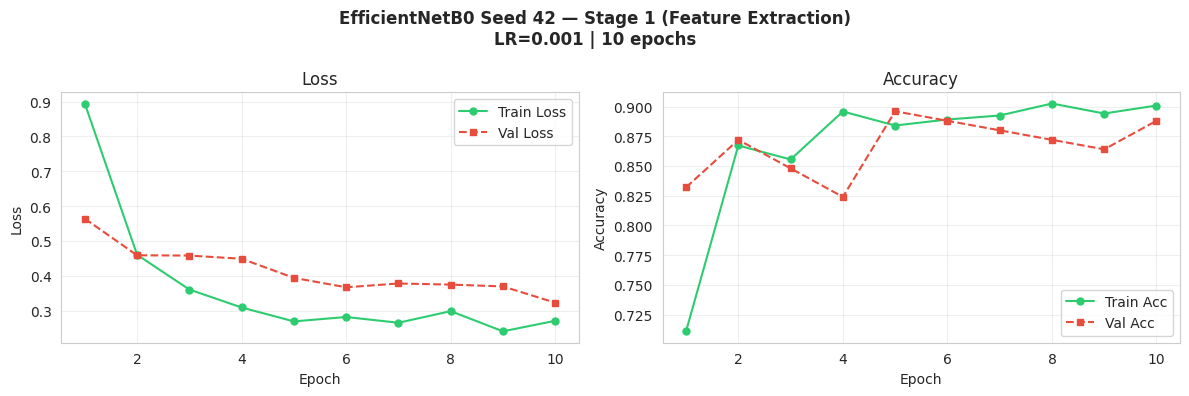

Saved: /kaggle/working/TUGAS-AKHIR/results/figures/phase_2/history_effnet_seed42_stage1.png


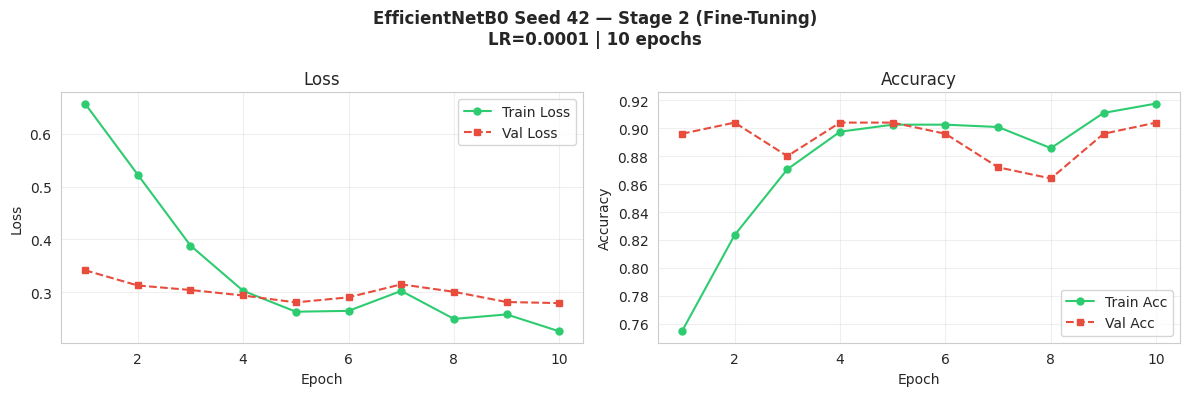

Saved: /kaggle/working/TUGAS-AKHIR/results/figures/phase_2/history_effnet_seed42_stage2.png


In [9]:
# ================================================================
# VISUALISASI: Plot TERPISAH untuk Stage 1 dan Stage 2
# Loss + Accuracy di masing-masing stage
# ================================================================

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Siapkan folder output
fig_dir = RESULTS_DIR / 'figures' / 'phase_2'
fig_dir.mkdir(parents=True, exist_ok=True)

# --- STAGE 1 ---
n_s1 = len(history_s1.history['loss'])
epochs_s1 = list(range(1, n_s1 + 1))

fig_s1, axes_s1 = plt.subplots(1, 2, figsize=(12, 4))
fig_s1.suptitle(f'EfficientNetB0 Seed {DEMO_SEED} — Stage 1 (Feature Extraction)\nLR={STAGE1_LR} | {n_s1} epochs', 
                fontsize=12, fontweight='bold')

# Loss
axes_s1[0].plot(epochs_s1, history_s1.history['loss'], 'o-', label='Train Loss', color='#2ecc71', ms=5)
axes_s1[0].plot(epochs_s1, history_s1.history['val_loss'], 's--', label='Val Loss', color='#e74c3c', ms=5)
axes_s1[0].set_xlabel('Epoch'); axes_s1[0].set_ylabel('Loss')
axes_s1[0].set_title('Loss'); axes_s1[0].legend(); axes_s1[0].grid(alpha=0.3)

# Accuracy
axes_s1[1].plot(epochs_s1, history_s1.history['accuracy'], 'o-', label='Train Acc', color='#2ecc71', ms=5)
axes_s1[1].plot(epochs_s1, history_s1.history['val_accuracy'], 's--', label='Val Acc', color='#e74c3c', ms=5)
axes_s1[1].set_xlabel('Epoch'); axes_s1[1].set_ylabel('Accuracy')
axes_s1[1].set_title('Accuracy'); axes_s1[1].legend(); axes_s1[1].grid(alpha=0.3)

plt.tight_layout()
path_s1 = fig_dir / f'history_effnet_seed{DEMO_SEED}_stage1.png'
plt.savefig(path_s1, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {path_s1}')

# --- STAGE 2 ---
n_s2 = len(history_s2.history['loss'])
epochs_s2 = list(range(1, n_s2 + 1))

fig_s2, axes_s2 = plt.subplots(1, 2, figsize=(12, 4))
fig_s2.suptitle(f'EfficientNetB0 Seed {DEMO_SEED} — Stage 2 (Fine-Tuning)\nLR={STAGE2_LR} | {n_s2} epochs', 
                fontsize=12, fontweight='bold')

# Loss
axes_s2[0].plot(epochs_s2, history_s2.history['loss'], 'o-', label='Train Loss', color='#2ecc71', ms=5)
axes_s2[0].plot(epochs_s2, history_s2.history['val_loss'], 's--', label='Val Loss', color='#e74c3c', ms=5)
axes_s2[0].set_xlabel('Epoch'); axes_s2[0].set_ylabel('Loss')
axes_s2[0].set_title('Loss'); axes_s2[0].legend(); axes_s2[0].grid(alpha=0.3)

# Accuracy
axes_s2[1].plot(epochs_s2, history_s2.history['accuracy'], 'o-', label='Train Acc', color='#2ecc71', ms=5)
axes_s2[1].plot(epochs_s2, history_s2.history['val_accuracy'], 's--', label='Val Acc', color='#e74c3c', ms=5)
axes_s2[1].set_xlabel('Epoch'); axes_s2[1].set_ylabel('Accuracy')
axes_s2[1].set_title('Accuracy'); axes_s2[1].legend(); axes_s2[1].grid(alpha=0.3)

plt.tight_layout()
path_s2 = fig_dir / f'history_effnet_seed{DEMO_SEED}_stage2.png'
plt.savefig(path_s2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {path_s2}')

## Langkah 9 — Evaluasi pada Test Set (seed=42)

In [10]:
y_true, y_pred = [], []
for batch_imgs, batch_lbls in ds_test:
    preds = model_demo.predict(batch_imgs, verbose=0)
    y_pred.extend(np.argmax(preds, axis=-1))
    y_true.extend(batch_lbls.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0)

print(f'Test Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
print(f'Test Precision : {prec:.4f}')
print(f'Test Recall   : {rec:.4f}')
print(f'Test F1       : {f1:.4f}')
print()
print('Classification Report:')
print(classification_report(y_true, y_pred,
      target_names=CLASS_NAMES, digits=4))

2026-09-13 12:55:50.649144: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-13 12:55:50.783615: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-13 12:55:51.094720: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-13 12:55:51.235536: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-13 12:55:51.991833: E external/local_xla/xla/stream_

Test Accuracy  : 0.8615 (86.15%)
Test Precision : 0.8881
Test Recall   : 0.8615
Test F1       : 0.8610

Classification Report:
              precision    recall  f1-score   support

    Berkabut     0.9286    1.0000    0.9630        26
     Berawan     1.0000    0.8462    0.9167        26
       Cerah     0.9565    0.8462    0.8980        26
       Hujan     0.8889    0.6154    0.7273        26
     Mendung     0.6667    1.0000    0.8000        26

    accuracy                         0.8615       130
   macro avg     0.8881    0.8615    0.8610       130
weighted avg     0.8881    0.8615    0.8610       130



## Langkah 10 — Confusion Matrix (Normalized)

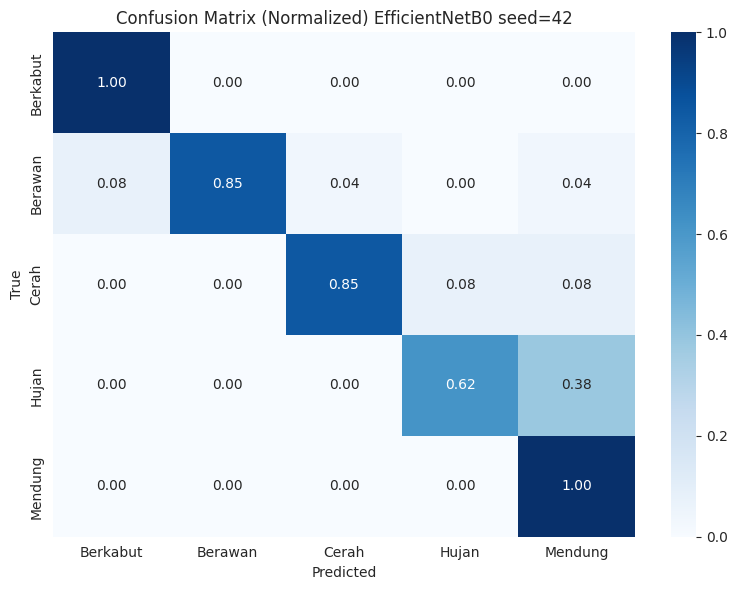

Saved: /kaggle/working/TUGAS-AKHIR/results/figures/phase 2/cm_effnet_seed42.png


In [11]:
cm = confusion_matrix(y_true, y_pred)
cm_n = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix (Normalized) EfficientNetB0 seed={DEMO_SEED}')
plt.tight_layout()
cm_path = RESULTS_DIR / 'figures' / 'phase 2' / f'cm_effnet_seed{DEMO_SEED}.png'
plt.savefig(cm_path, dpi=150)
plt.show()
print('Saved:', cm_path)

## Langkah 11 — Simpan Metrics seed=42

In [13]:
metrics = {
    'architecture': 'efficientnetb0',
    'seed': DEMO_SEED,
    'test_accuracy': float(acc),
    'test_precision': float(prec),
    'test_recall': float(rec),
    'test_f1': float(f1),
    'epochs_stage1': EPOCHS_STAGE1,
    'epochs_stage2': EPOCHS_STAGE2,
    'time_stage1_s': float(t_s1),
    'time_stage2_s': float(t_s2),
}

metrics_json = RESULTS_DIR / 'json' / f'metrics_effnet_seed{DEMO_SEED}.json'
with open(metrics_json, 'w') as f:
    json.dump(metrics, f, indent=2)
print('Saved:', metrics_json)

Saved: /kaggle/working/TUGAS-AKHIR/results/json/metrics_effnet_seed42.json


## Langkah 12 — Full Pipeline: Semua 5 Seed

**Jalankan cell ini SETELAH cell 1-11 (demo seed=42) selesai dan berhasil.**

Setiap seed dijalankan sequential. Model dihapus dari memory antar seed.

In [14]:
import gc
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

print('='*60)
print('FULL PIPELINE — EfficientNetB0 x 5 seeds')
print('='*60)

# Folder untuk plot
fig_dir = RESULTS_DIR / 'figures' / 'phase_2'
fig_dir.mkdir(parents=True, exist_ok=True)

t_start = time.time()

for seed in SEEDS:
    print()
    print('='*60)
    print(f'SEED {seed} ({SEEDS.index(seed)+1}/{len(SEEDS)})')
    print('='*60)

    ds_tr = build_tf_dataset(
        seed=seed, subset='train',
        preprocess_fn=preprocess_eff, augment=True, batch_size=32)
    ds_vl = build_tf_dataset(
        seed=seed, subset='val',
        preprocess_fn=preprocess_eff, augment=False, batch_size=32)

    ckpt = str(MODELS_DIR/ 'efficientnetb0' / f'efficientnetb0_seed{seed}.keras')
    result = train_two_stage(
        architecture='efficientnetb0',
        seed=seed,
        preprocess_fn=preprocess_eff,
        ds_train=ds_tr,
        ds_val=ds_vl,
        checkpoint_path=ckpt,
        verbose=1)

    # ================================================
    # PLOT: Training History per Seed (Terpisah)
    # ================================================
    n_s1 = len(result['stage1'].history['loss'])
    epochs_s1 = list(range(1, n_s1 + 1))
    n_s2 = len(result['stage2'].history['loss'])
    epochs_s2 = list(range(1, n_s2 + 1))

    # --- Stage 1 ---
    fig_s1, axes_s1 = plt.subplots(1, 2, figsize=(12, 4))
    fig_s1.suptitle(f'EfficientNetB0 Seed {seed} — Stage 1 (Feature Extraction)\nLR={STAGE1_LR} | {n_s1} epochs', 
                    fontsize=12, fontweight='bold')
    axes_s1[0].plot(epochs_s1, result['stage1'].history['loss'], 'o-', label='Train Loss', color='#2ecc71', ms=5)
    axes_s1[0].plot(epochs_s1, result['stage1'].history['val_loss'], 's--', label='Val Loss', color='#e74c3c', ms=5)
    axes_s1[0].set_xlabel('Epoch'); axes_s1[0].set_ylabel('Loss')
    axes_s1[0].set_title('Loss'); axes_s1[0].legend(); axes_s1[0].grid(alpha=0.3)
    axes_s1[1].plot(epochs_s1, result['stage1'].history['accuracy'], 'o-', label='Train Acc', color='#2ecc71', ms=5)
    axes_s1[1].plot(epochs_s1, result['stage1'].history['val_accuracy'], 's--', label='Val Acc', color='#e74c3c', ms=5)
    axes_s1[1].set_xlabel('Epoch'); axes_s1[1].set_ylabel('Accuracy')
    axes_s1[1].set_title('Accuracy'); axes_s1[1].legend(); axes_s1[1].grid(alpha=0.3)
    plt.tight_layout()
    path_s1 = fig_dir / f'history_effnet_seed{seed}_stage1.png'
    plt.savefig(path_s1, dpi=150, bbox_inches='tight')
    plt.close('all')
    print(f'  [Plot] Saved: {path_s1.name}')

    # --- Stage 2 ---
    fig_s2, axes_s2 = plt.subplots(1, 2, figsize=(12, 4))
    fig_s2.suptitle(f'EfficientNetB0 Seed {seed} — Stage 2 (Fine-Tuning)\nLR={STAGE2_LR} | {n_s2} epochs', 
                    fontsize=12, fontweight='bold')
    axes_s2[0].plot(epochs_s2, result['stage2'].history['loss'], 'o-', label='Train Loss', color='#2ecc71', ms=5)
    axes_s2[0].plot(epochs_s2, result['stage2'].history['val_loss'], 's--', label='Val Loss', color='#e74c3c', ms=5)
    axes_s2[0].set_xlabel('Epoch'); axes_s2[0].set_ylabel('Loss')
    axes_s2[0].set_title('Loss'); axes_s2[0].legend(); axes_s2[0].grid(alpha=0.3)
    axes_s2[1].plot(epochs_s2, result['stage2'].history['accuracy'], 'o-', label='Train Acc', color='#2ecc71', ms=5)
    axes_s2[1].plot(epochs_s2, result['stage2'].history['val_accuracy'], 's--', label='Val Acc', color='#e74c3c', ms=5)
    axes_s2[1].set_xlabel('Epoch'); axes_s2[1].set_ylabel('Accuracy')
    axes_s2[1].set_title('Accuracy'); axes_s2[1].legend(); axes_s2[1].grid(alpha=0.3)
    plt.tight_layout()
    path_s2 = fig_dir / f'history_effnet_seed{seed}_stage2.png'
    plt.savefig(path_s2, dpi=150, bbox_inches='tight')
    plt.close('all')
    print(f'  [Plot] Saved: {path_s2.name}')

    # ================================================
    # EVALUASI & SIMPAN METRIK
    # ================================================
    model = result['model']
    y_t, y_p = [], []
    ds_ts = build_tf_dataset(
        seed=seed, subset='test',
        preprocess_fn=preprocess_eff, augment=False, batch_size=32)
    for bi, bl in ds_ts:
        pr = model.predict(bi, verbose=0)
        y_p.extend(np.argmax(pr, axis=-1))
        y_t.extend(bl.numpy())
    y_t, y_p = np.array(y_t), np.array(y_p)
    ac = accuracy_score(y_t, y_p)
    pr_m, rc_m, f1_m, _ = precision_recall_fscore_support(
        y_t, y_p, average='macro', zero_division=0)
    m = {
        'architecture': 'efficientnetb0',
        'seed': seed,
        'test_accuracy': float(ac),
        'test_f1': float(f1_m),
        'epochs_stage1': EPOCHS_STAGE1,
        'epochs_stage2': EPOCHS_STAGE2,
        'time_stage1_s': float(result.get('t_stage1', 0)),
        'time_stage2_s': float(result.get('t_stage2', 0)),
    }
    mp = RESULTS_DIR / f'metrics_effnet_seed{seed}.json'
    with open(mp, 'w') as f:
        json.dump(m, f, indent=2)
    print(f'  [Metrics] Seed {seed} | acc={ac:.4f} f1={f1_m:.4f} | saved: {mp.name}')

    # Cleanup GPU memory
    del model, ds_tr, ds_vl, ds_ts
    gc.collect()
    tf.keras.backend.clear_session()

t_total = time.time() - t_start
print()
print('='*60)
print(f'ALL 5 SEEDS DONE in {t_total:.0f}s ({t_total/60:.1f} min)')
print('='*60)

FULL PIPELINE — EfficientNetB0 x 5 seeds

SEED 42 (1/5)
Found 595 files belonging to 5 classes.
Found 125 files belonging to 5 classes.
Building efficientnetb0 (seed=42)
Model      : efficientnetb0
Input shape: (None, 224, 224, 3)
Output     : (None, 5)
Trainable layers : 9
Frozen layers    : 0
Total parameters: 4,715,176

STAGE 1 — Freeze base model, LR=1e-03
  Epochs    : 10
  Callbacks : EarlyStopping(p=5), ReduceLROnPlateau(f=0.5,p=5), ModelCheckpoint(val_accuracy)

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 834ms/step - accuracy: 0.5888 - loss: 1.2889
Epoch 1: val_accuracy improved from None to 0.78400, saving model to /kaggle/working/TUGAS-AKHIR/models/efficientnetb0/efficientnetb0_seed42_stage1.keras

Epoch 1: finished saving model to /kaggle/working/TUGAS-AKHIR/models/efficientnetb0/efficientnetb0_seed42_stage1.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.7092 - loss: 0.9496 - val_accuracy: 0.7840 - val_loss: 0.6186 - learning_rate: 0.0010
Epoch 2/10
18/19 ━━━━━━━━━

## Langkah 13 — Summary Semua Seed

In [15]:
all_metrics = []
for seed in SEEDS:
    mp = RESULTS_DIR / f'metrics_effnet_seed{seed}.json'
    if mp.exists():
        with open(mp) as f:
            all_metrics.append(json.load(f))

if all_metrics:
    df = pd.DataFrame(all_metrics)
    print('=== SUMMARY ===')
    print(df[['seed','test_accuracy','test_f1']].to_string(index=False))
    print()
    print(f"Mean accuracy : {df['test_accuracy'].mean():.4f} +/- {df['test_accuracy'].std():.4f}")
    print(f"Mean F1 macro : {df['test_f1'].mean():.4f} +/- {df['test_f1'].std():.4f}")
    sum_path = RESULTS_DIR / 'metrics_effnet_summary.csv'
    df.to_csv(sum_path, index=False)
    print('Saved:', sum_path)

=== SUMMARY ===
 seed  test_accuracy  test_f1
   42       0.884615 0.887545
  123       0.869231 0.869300
 2024       0.884615 0.884301
    7       0.900000 0.902052
   99       0.900000 0.900370

Mean accuracy : 0.8877 +/- 0.0129
Mean F1 macro : 0.8887 +/- 0.0133
Saved: /kaggle/working/TUGAS-AKHIR/results/metrics_effnet_summary.csv
